In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# Load data

In [21]:
path = kagglehub.dataset_download("joebeachcapital/top-500-hollywood-movies-of-all-time")

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
movies_df = pd.read_csv(os.path.join(path, "Most Profitable Movies of All Time - Top 500 Movies.csv"))

movies_df.head()

,title,worldwide gross (m),% budget recovered,X times budget recovered,budget (millions),domestic gross (m),domestic %,international gross (m),% of gross from international,worldwide gross,year,decade,source,budget source,force label,horror
0,300,456.0,702%,7.0,65.0,211.0,46.2%,245.0,53.8%,456082343,2007,2000's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror
1,1917,385.0,427%,4.3,90.0,159.0,41.4%,225.0,58.6%,384576334,2019,2010's,https://www.boxofficemojo.com/chart/ww_top_lif...,https://www.nytimes.com/2020/01/12/movies/1917...,NaN,not horror
2,2012,791.0,396%,4.0,200.0,166.0,21.0%,625.0,79.0%,791217826,2009,2000's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror
3,101 Dalmatians,321.0,479%,4.8,67.0,136.0,42.5%,185.0,57.5%,320689294,1996,1990's,https://www.boxofficemojo.com/chart/ww_top_lif...,https://en.wikipedia.org/wiki/101_Dalmatians_(...,NaN,not horror
4,22 Jump Street,331.0,663%,6.6,50.0,192.0,57.9%,140.0,42.1%,331333876,2014,2010's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror


# Data cleaning

In [15]:
# cek missing values
missing_values = movies_df.isnull().sum()

# cek duplicate rows
duplicate_rows = movies_df.duplicated().sum()

# cek data types
data_types = movies_df.dtypes

missing_values, duplicate_rows, data_types

(title                              0
 worldwide gross (m)                0
 % budget recovered                 0
 X times budget recovered           0
 budget  (millions)                 0
 domestic gross (m)                 0
 domestic %                         0
 international gross (m)            0
 % of gross from international      0
 worldwide gross                    0
 year                               0
 decade                             0
 source                            81
 budget source                    163
 force label                      557
 horror                             0
 dtype: int64,
 np.int64(0),
 title                                str
 worldwide gross (m)              float64
 % budget recovered                   str
 X times budget recovered         float64
 budget  (millions)               float64
 domestic gross (m)               float64
 domestic %                           str
 international gross (m)          float64
 % of gross from internatio

In [43]:
# ganti nama kolom
movies_df = movies_df.rename(columns={
    'budget  (millions)': 'budget_millions',
    'worldwide gross (m)': 'worldwide_gross_m'
})

# rumus regresi
formula = "worldwide_gross_m ~ budget_millions"

# fit model
model = ols(formula, data=movies_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      worldwide_gross_m   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     358.3
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           3.90e-62
Time:                        09:13:58   Log-Likelihood:                -3962.3
No. Observations:                 562   AIC:                             7929.
Df Residuals:                     560   BIC:                             7937.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         214.1501     20.558     

## EDA

## Statistik deskriptif

In [45]:
movies_df[['budget_millions', 'worldwide_gross_m']].describe()

,budget_millions,worldwide_gross_m
count,562.000000,562.000000
mean,108.460614,532.883986
std,76.027601,357.689672
min,0.015000,4.000000
25%,43.250000,342.000000
50%,100.000000,432.000000
75%,165.000000,667.750000
max,379.000000,2923.000000


## Distribusi variabel X dan Y

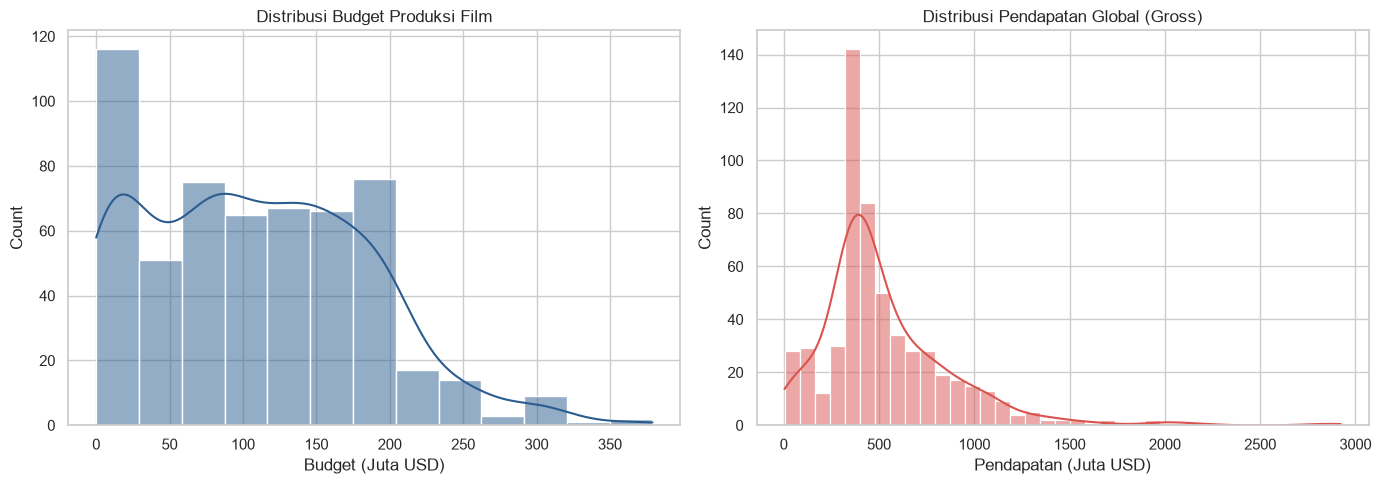

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# budget
sns.histplot(movies_df['budget_millions'], kde=True, color='#2b5c8f', ax=ax[0])
ax[0].set_title('Distribusi Budget Produksi Film')
ax[0].set_xlabel('Budget (Juta USD)')

# gross
sns.histplot(movies_df['worldwide_gross_m'], kde=True, color='#d9534f', ax=ax[1])
ax[1].set_title('Distribusi Pendapatan Global (Gross)')
ax[1].set_xlabel('Pendapatan (Juta USD)')

plt.tight_layout()
plt.show()

## Cek outlier

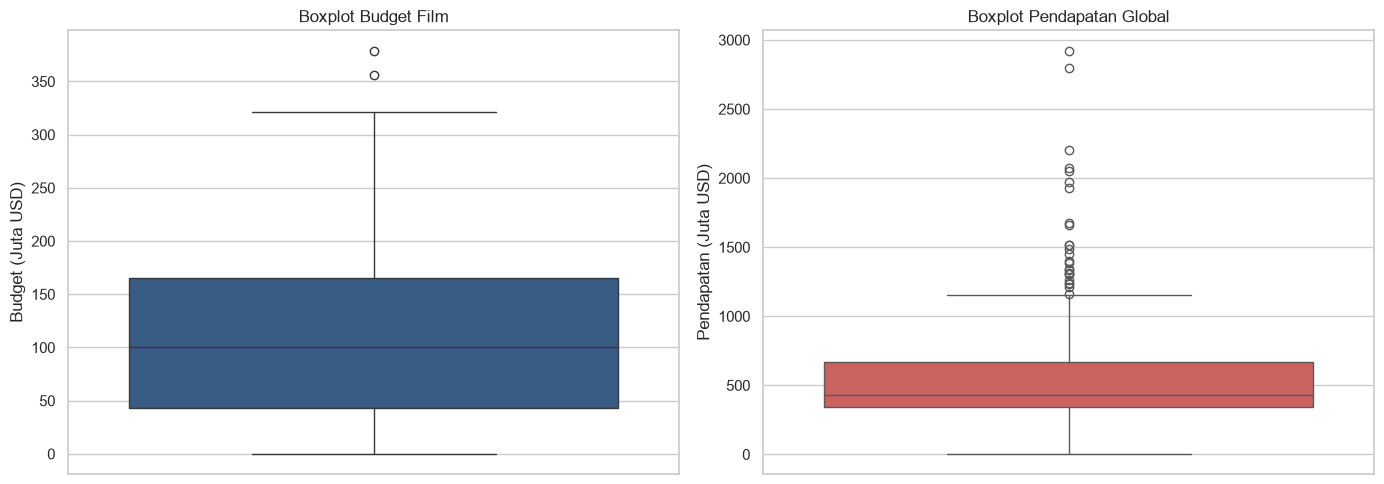

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# budget
sns.boxplot(y=movies_df['budget_millions'], color='#2b5c8f', ax=ax[0])
ax[0].set_title('Boxplot Budget Film')
ax[0].set_ylabel('Budget (Juta USD)')

# gross
sns.boxplot(y=movies_df['worldwide_gross_m'], color='#d9534f', ax=ax[1])
ax[1].set_title('Boxplot Pendapatan Global')
ax[1].set_ylabel('Pendapatan (Juta USD)')

plt.tight_layout()
plt.show()

## Hubungan antar variabel

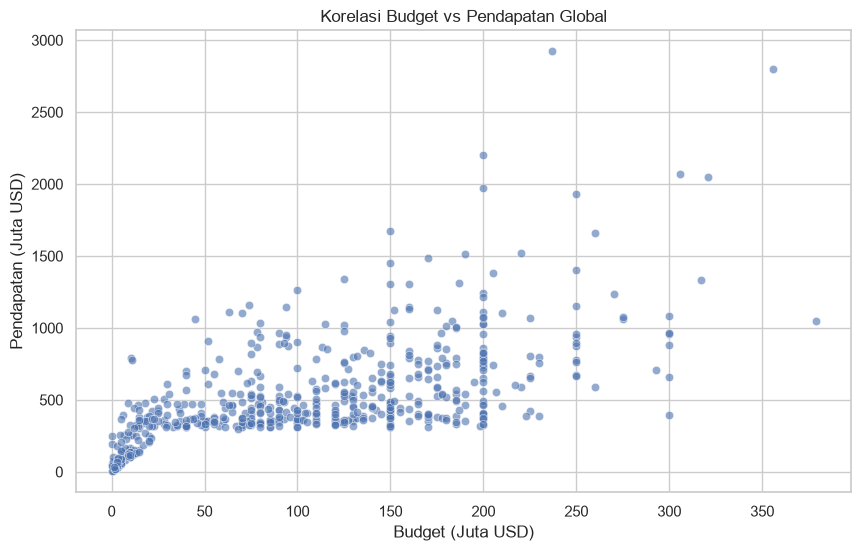

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movies_df, x='budget_millions', y='worldwide_gross_m', alpha=0.6)
plt.title('Korelasi Budget vs Pendapatan Global')
plt.xlabel('Budget (Juta USD)')
plt.ylabel('Pendapatan (Juta USD)')
plt.show()

## Uji hipotesis

### Hipotesis

H0: $\beta_1=0$ (Anggaran produksi tidak memengaruhi pendapatan global secara signifikan.) <br>
H1: $\beta_1 \neq 0$ (Anggaran produksi memengaruhi pendapatan global secara signifikan.)

### Nilai kritis

In [60]:
alpha = 0.05
z_kritis = stats.norm.ppf(1 - alpha/2)

print(f"Taraf signifikansi \u03b1: {alpha}")
print(f"Nilai kritis: +/- {z_kritis:.3f}")

Taraf signifikansi α: 0.05
Nilai kritis: +/- 1.960


### Statistik uji

In [62]:
z_hitung = model_robust.tvalues['budget_millions']
p_value = model_robust.pvalues['budget_millions']

print(f"Statistik uji (z-hitung): {z_hitung:.3f}")
print(f"p-value: {p_value:.6f}")

Statistik uji (z-hitung): 13.080
p-value: 0.000000


### Keputusan

In [ ]:
# nilai Z
if abs(z_hitung) > z_kritis:
    print(f"Z-Hitung ({abs(z_hitung):.3f}) > Z-Tabel ({z_kritis:.3f}) -> TOLAK H0")
else:
    print(f"Z-Hitung ({abs(z_hitung):.3f}) <= Z-Tabel ({z_kritis:.3f}) -> GAGAL TOLAK H0")

# p-value
if p_value < alpha:
    print(f"P-Value ({p_value:.6f}) < Alpha ({alpha}) -> TOLAK H0")
else:
    print(f"P-Value ({p_value:.6f}) >= Alpha ({alpha}) -> GAGAL TOLAK H0")

Z-Hitung (13.080) > Z-Tabel (1.960) -> TOLAK H0
P-Value (0.000000) < Alpha (0.05) -> TOLAK H0


### Kesimpulan

In [66]:
if p_value < alpha:
    print("Dengan tingkat keyakinan 95%, terdapat cukup bukti empiris untuk menolak H0.")
    print("Artinya, anggaran produksi terbukti memiliki pengaruh yang positif dan signifikan terhadap pendapatan kotor global.")
else:
    print("Tidak cukup bukti empiris untuk menolak H0.")
    print("Artinya, anggaran produksi tidak terbukti memengaruhi pendapatan kotor global secara signifikan.")

Dengan tingkat keyakinan 95%, terdapat cukup bukti empiris untuk menolak H0.
Artinya, anggaran produksi terbukti memiliki pengaruh yang positif dan signifikan terhadap pendapatan kotor global.


# Model regresi linear sederhana

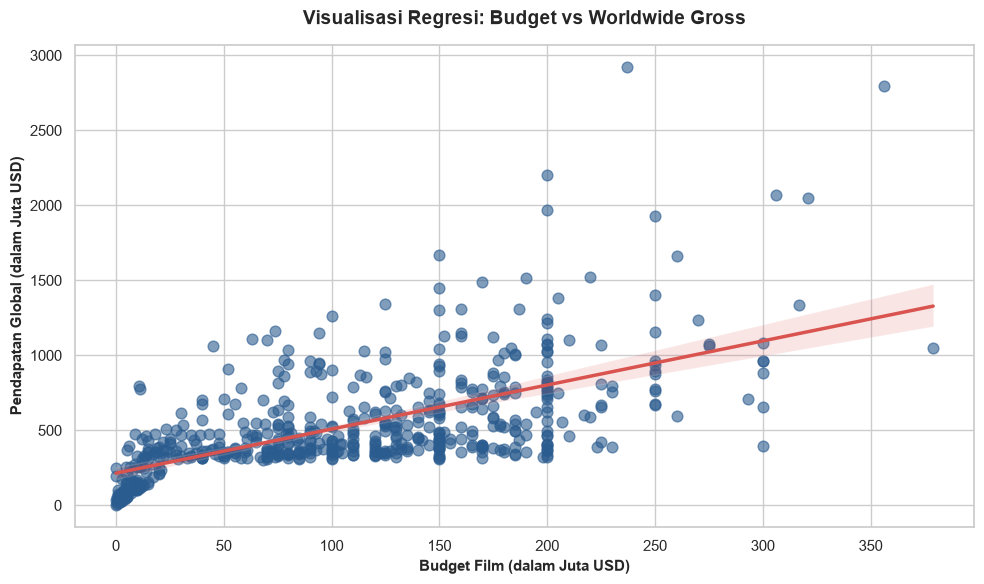

In [44]:
# tema
sns.set_theme(style="whitegrid")

# ukuran grafik
plt.figure(figsize=(10, 6))

# scatter plot, garis regresi
sns.regplot(
    data=movies_df, 
    x="budget_millions", 
    y="worldwide_gross_m",
    scatter_kws={'color': '#2b5c8f', 'alpha': 0.6, 's': 60},
    line_kws={'color': '#d9534f', 'linewidth': 2.5}
)

# judul, label sumbu
plt.title("Visualisasi Regresi: Budget vs Worldwide Gross", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Budget Film (dalam Juta USD)", fontsize=11, fontweight='bold')
plt.ylabel("Pendapatan Global (dalam Juta USD)", fontsize=11, fontweight='bold')

# grafik
plt.tight_layout()
plt.show()

# Uji asumsi

In [31]:
residuals = model.resid
exog_variables = model.model.exog

## Uji normalitas residual (Jarque-Bera, Saphiro-Wilk)

In [82]:
jb_pvalue = jarque_bera(residuals)[1]
shapiro_stat, shapiro_pvalue = stats.shapiro(residuals)

print("Uji normalitas residual:")
print("H0: Residual berdistribusi normal (p-value > 0.05)")
print(f"Jarque-Bera p-value: {jb_pvalue:.4f} -> {'Normal (terpenuhi)' if jb_pvalue > 0.05 else 'Tidak normal (melanggar)'}")
print(f"Shapiro-Wilk p-value: {shapiro_pvalue:.4f} -> {'Normal (terpenuhi)' if shapiro_pvalue > 0.05 else 'Tidak normal (melanggar)'}")
print("\n")

Uji normalitas residual:
H0: Residual berdistribusi normal (p-value > 0.05)
Jarque-Bera p-value: 0.0000 -> Tidak normal (melanggar)
Shapiro-Wilk p-value: 0.0000 -> Tidak normal (melanggar)




In [80]:
# kolom baru di dataframe
movies_df['log_budget'] = np.log(movies_df['budget_millions'])
movies_df['log_gross'] = np.log(movies_df['worldwide_gross_m'])

# model regresi linear dengan data yang sudah di-log
formula_log = "log_gross ~ log_budget"
model_log = ols(formula_log, data=movies_df).fit()

print("Hasil regresi setelah transformasi log:")
print(model_log.summary())
print("\n" + "="*50 + "\n")

# uji ulang asumsi normalitas pada model baru
residuals_log = model_log.resid

jb_pvalue_log = jarque_bera(residuals_log)[1]
shapiro_stat_log, shapiro_pvalue_log = stats.shapiro(residuals_log)

print("Uji normalitas setelah log natural:")
print(f"Jarque-Bera p-value: {jb_pvalue_log:.4f} -> {'Normal (terpenuhi)' if jb_pvalue_log > 0.05 else 'Tidak normal (melanggar)'}")
print(f"Shapiro-Wilk p-value: {shapiro_pvalue_log:.4f} -> {'Normal (terpenuhi)' if shapiro_pvalue_log > 0.05 else 'Tidak normal (melanggar)'}")

Hasil regresi setelah transformasi log:
                            OLS Regression Results                            
Dep. Variable:              log_gross   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.632
Method:                 Least Squares   F-statistic:                     962.6
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          9.81e-124
Time:                        11:04:10   Log-Likelihood:                -388.94
No. Observations:                 562   AIC:                             781.9
Df Residuals:                     560   BIC:                             790.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   

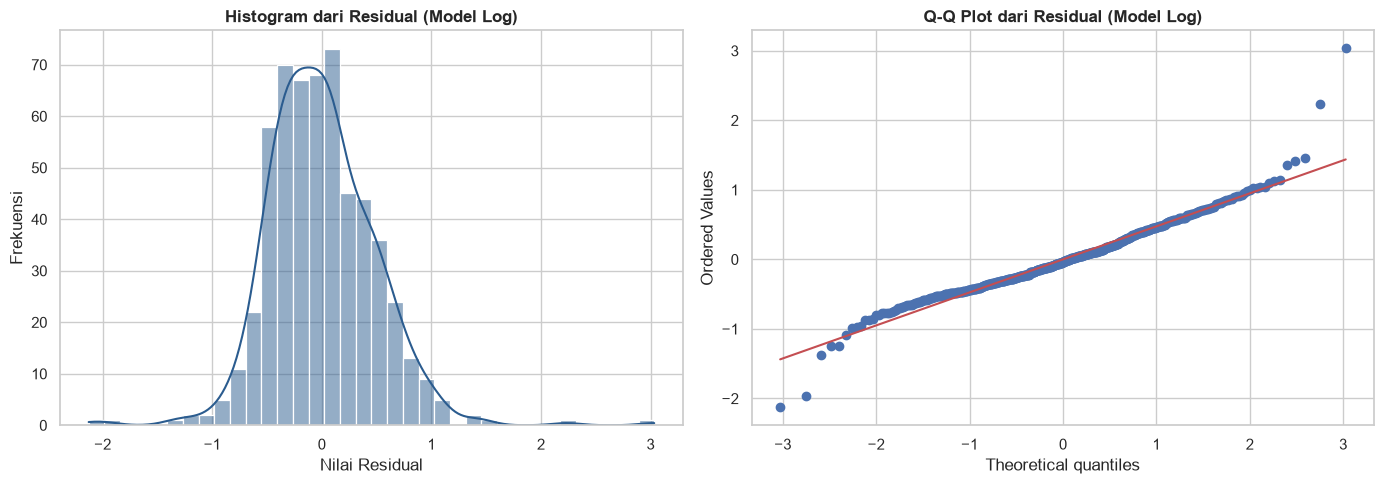

In [77]:
# tata letak grafik
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# histogram residual
sns.histplot(residuals_log, kde=True, ax=ax[0], color='#2b5c8f')
ax[0].set_title('Histogram dari Residual (Model Log)', fontweight='bold')
ax[0].set_xlabel('Nilai Residual')
ax[0].set_ylabel('Frekuensi')

# Q-Q Plot
stats.probplot(residuals_log, dist="norm", plot=ax[1])
ax[1].set_title('Q-Q Plot dari Residual (Model Log)', fontweight='bold')

plt.tight_layout()
plt.show()

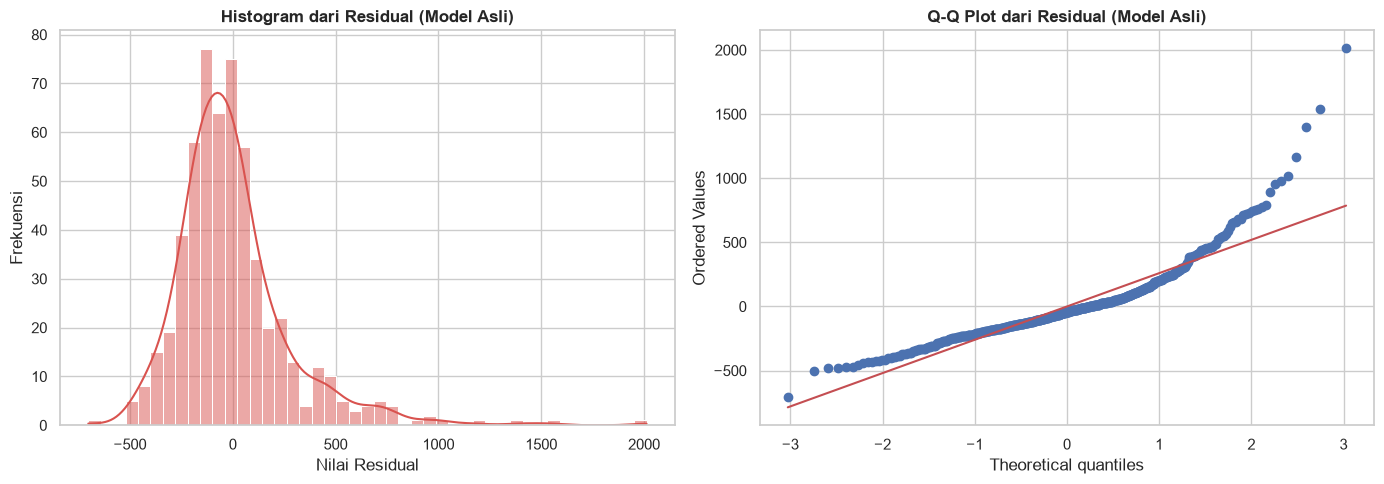

In [75]:
# nilai residual dari model regresi awal (non-log)
residuals_asli = model.resid

# tata letak grafik
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# histogram residual
sns.histplot(residuals_asli, kde=True, ax=ax[0], color='#d9534f')
ax[0].set_title('Histogram dari Residual (Model Asli)', fontweight='bold')
ax[0].set_xlabel('Nilai Residual')
ax[0].set_ylabel('Frekuensi')

# Q-Q Plot
stats.probplot(residuals_asli, dist="norm", plot=ax[1])
ax[1].set_title('Q-Q Plot dari Residual (Model Asli)', fontweight='bold')

plt.tight_layout()
plt.show()

## Uji heteroskedastisitas

In [74]:
# nilai residual dan variabel prediktor dari model asli
residuals_asli = model.resid
exog_asli = model.model.exog  # exog ini berisi nilai intersep dan variabel budget_millions

# uji Breusch-Pagan
bp_test_results = het_breuschpagan(residuals_asli, exog_asli)
bp_pvalue = bp_test_results[1]

# hasil
print("Uji heteroskedastisitas")
print("H0: Varian residual konstan (homoskedastis)")
print("H1: Varian residual tidak konstan (heteroskedastis)\n")

print(f"Nilai p-value Breusch-Pagan: {bp_pvalue:.4f}")

if bp_pvalue > 0.05:
    print("Kesimpulan: Gagal tolak H0, model aman dari heteroskedastisitas (Homoskedastis).")
else:
    print("Kesimpulan: Tolak H0, terdapat gejala heteroskedastisitas pada model (melanggar asumsi).")

Uji heteroskedastisitas
H0: Varian residual konstan (homoskedastis)
H1: Varian residual tidak konstan (heteroskedastis)

Nilai p-value Breusch-Pagan: 0.0000
Kesimpulan: Tolak H0, terdapat gejala heteroskedastisitas pada model (melanggar asumsi).


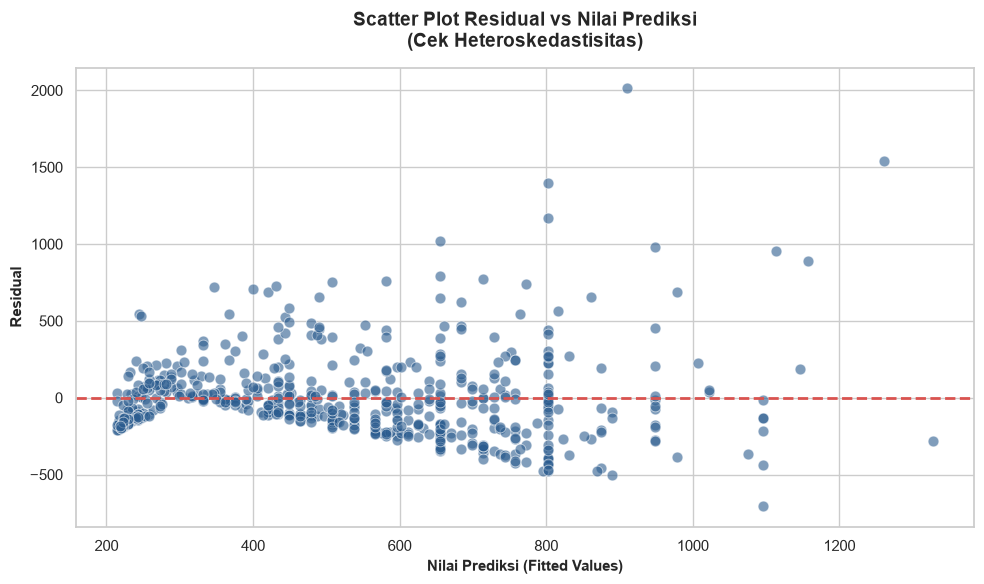

In [70]:
# nilai rrediksi dan residual dari model asli
fitted_values = model.fittedvalues
residuals_asli = model.resid

# ukuran grafik
plt.figure(figsize=(10, 6))

# scatter plot (fitted vs residual)
sns.scatterplot(
    x=fitted_values, 
    y=residuals_asli, 
    color='#2b5c8f', 
    alpha=0.6, 
    s=60
)

# garis nol sebagai batas tengah error
plt.axhline(y=0, color='#d9534f', linestyle='--', linewidth=2)

# judul dan label
plt.title('Scatter Plot Residual vs Nilai Prediksi\n(Cek Heteroskedastisitas)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Prediksi (Fitted Values)', fontsize=11, fontweight='bold')
plt.ylabel('Residual', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [69]:
formula = "worldwide_gross_m ~ budget_millions"

# tambahkan cov_type='HC3'
model_robust = ols(formula, data=movies_df).fit(cov_type='HC3')

print("Hasil regresi dengan robust standard errors:")
print(model_robust.summary())

Hasil regresi dengan robust standard errors:
                            OLS Regression Results                            
Dep. Variable:      worldwide_gross_m   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     171.1
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.64e-34
Time:                        10:54:14   Log-Likelihood:                -3962.3
No. Observations:                 562   AIC:                             7929.
Df Residuals:                     560   BIC:                             7937.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

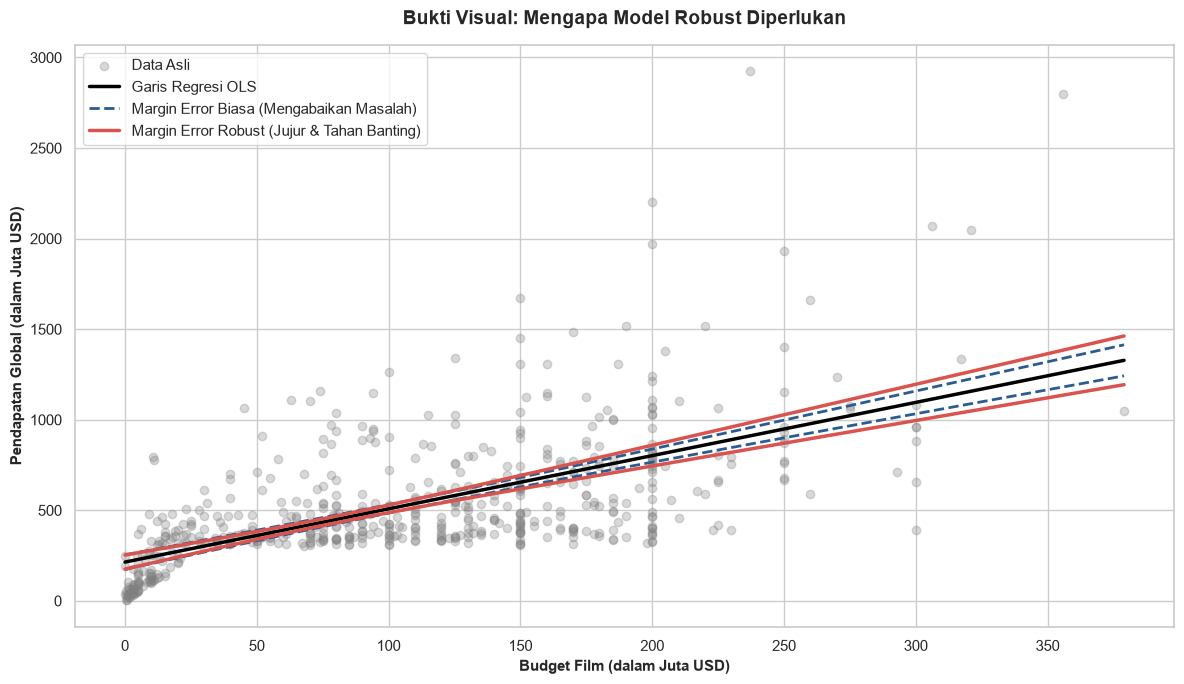

In [67]:
# rentang X
x_range = pd.DataFrame({'budget_millions': np.linspace(movies_df['budget_millions'].min(), movies_df['budget_millions'].max(), 100)})

# nilai prediksi & batas confidence interval
pred_biasa = model.get_prediction(x_range).summary_frame(alpha=0.05)
pred_robust = model_robust.get_prediction(x_range).summary_frame(alpha=0.05)

# grafik
plt.figure(figsize=(12, 7))

# scatter plot
plt.scatter(movies_df['budget_millions'], movies_df['worldwide_gross_m'], color='grey', alpha=0.3, label='Data Asli')

# garis regresi
plt.plot(x_range['budget_millions'], pred_biasa['mean'], color='black', linewidth=2.5, label='Garis Regresi OLS')

# model biasa
plt.plot(x_range['budget_millions'], pred_biasa['mean_ci_upper'], color='#2b5c8f', linestyle='--', linewidth=2, label='Margin Error Biasa (Mengabaikan Masalah)')
plt.plot(x_range['budget_millions'], pred_biasa['mean_ci_lower'], color='#2b5c8f', linestyle='--', linewidth=2)

# model robust HC3
plt.plot(x_range['budget_millions'], pred_robust['mean_ci_upper'], color='#d9534f', linestyle='-', linewidth=2.5, label='Margin Error Robust (Jujur & Tahan Banting)')
plt.plot(x_range['budget_millions'], pred_robust['mean_ci_lower'], color='#d9534f', linestyle='-', linewidth=2.5)

# visual
plt.title("Bukti Visual: Mengapa Model Robust Diperlukan", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Budget Film (dalam Juta USD)", fontsize=11, fontweight='bold')
plt.ylabel("Pendapatan Global (dalam Juta USD)", fontsize=11, fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()